<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/PLN/Analisis_Texto_261554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Autor: Juan Francisco Gámez Cortés.
Matricula: 261554 MArzo de 2026

Materia: Procesamiento de Lenguaje Natural

**Actividad:** Analice el siguiente texto y aplique las técnicas de PLN que crea necesarias (nube de palabras, gráficas, lemas, stopwords, limpieza, etc.). Instale las librearías necesarias. Desarrolle su script de Python implementando el código en funciones. Describa el efecto de las técnicas utilizadas al ser aplicadas al texto al ser procesado.

texto = """

En el Congreso Internacional de Inteligencia Artificial 2025 se discutieron avances muy importantes.

@Maria comentó que la ética de la IA debe estar siempre en el centro de las investigaciones.

Puedes leer más en http://ia-congreso2025.org o enviar tus dudas al correo contacto@ia2025.org.

El Dr. Pérez afirmó: "¡La innovación no se detiene!". #InteligenciaArtificial #ÉticaDigital

Además, varios expertos señalaron que la inteligencia artificial, la inteligencia artificial

y la inteligencia artificial aparecen repetidamente en los debates académicos."""

In [59]:
# ==============================
# 1. Importación de librerías
# ==============================
import re
import pandas as pd
import spacy
import nltk
import unicodedata
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords

In [60]:
# Descargar recursos necesarios
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [61]:
# Cargar modelo de spaCy para español
import spacy

try:
    nlp = spacy.load("es_core_news_sm")
except OSError:
    print("Descargando modelo 'es_core_news_sm' para spaCy...")
    !python -m spacy download es_core_news_sm
    nlp = spacy.load("es_core_news_sm")

In [62]:
texto = """
En el Congreso Internacional de Inteligencia Artificial 2025 se discutieron avances muy importantes.
@Maria comentó que la ética de la IA debe estar siempre en el centro de las investigaciones.
Puedes leer más en http://ia-congreso2025.org o enviar tus dudas al correo contacto@ia2025.org.
El Dr. Pérez afirmó: "¡La innovación no se detiene!". #InteligenciaArtificial #ÉticaDigital
Además, varios expertos señalaron que la inteligencia artificial, la inteligencia artificial
y la inteligencia artificial aparecen repetidamente en los debates académicos.
"""

###Conversión a minúsculas

In [63]:
def convertir_minusculas(texto: str) -> str:
    """
    Convierte texto a minúsculas.

    Args:
        texto: Texto a convertir

    Returns:
        Texto en minúsculas
    """
    if pd.isna(texto):
        return ""
    return str(texto).lower()

###Eliminación de puntuaciones

In [64]:
def eliminar_puntuacion(texto: str) -> str:
    """
    Elimina los signos de puntuación del texto.

    Args:
        texto: Texto a procesar

    Returns:
        Texto sin puntuación
    """
    if pd.isna(texto):
        return ""
    clean_text = re.sub(r'[^\w\s]', '', texto)
    return str(clean_text)

###Eliminación de URLs


In [77]:
def eliminar_urls(texto: str) -> str:
    """
    Elimina URLs del texto.

    Args:
        texto: Texto a procesar

    Returns:
        Texto sin URLs
    """
    if pd.isna(texto):
        return ""

    patron = r'https?://\S+|www\.\S+'
    resultado = re.sub(patron, '', str(texto))

    # Elimina espacios múltiples que quedan tras borrar la URL
    resultado = re.sub(r' +', ' ', resultado)

    return resultado.strip()

###Eliminación de acentos

In [66]:
def eliminar_acentos(texto: str) -> str:
    """
    Elimina acentos y diacríticos del texto.

    Args:
        texto: Texto con acentos

    Returns:
        Texto sin acentos
    """
    if pd.isna(texto):
        return ""

    # Normalizar el texto y eliminar diacríticos
    texto_nfd = unicodedata.normalize('NFD', str(texto))
    resultado = ''.join(char for char in texto_nfd if unicodedata.category(char) != 'Mn')

    return resultado

### Tokenizar

In [67]:
def tokenizar_visualizar(texto: str, nlp, top_n: int = 10) -> list[str]:
    """
    Tokeniza un texto con spaCy y genera visualizaciones de frecuencia y WordCloud.

    Args:
        texto:  Texto a procesar.
        nlp:    Modelo de spaCy cargado (ej: spacy.load('es_core_news_sm')).
        top_n:  Cantidad de palabras más frecuentes a mostrar en el gráfico de barras.

    Returns:
        Lista de tokens crudos extraídos del texto.
    """
    # Tokenización
    doc = nlp(texto)
    tokens = [token.text for token in doc]
    print("\n=== Tokens ===")
    print(tokens)

    # Frecuencia de palabras
    counter = Counter(tokens)
    most_common = counter.most_common(top_n)
    palabras, freqs = zip(*most_common)

    plt.figure(figsize=(10, 5))
    plt.bar(palabras, freqs)
    plt.title(f"Frecuencia de palabras - Top {top_n} (tokens crudos)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # WordCloud
    text_joined = " ".join(tokens)
    wc = WordCloud(width=800, height=400, background_color="white").generate(text_joined)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud de tokens crudos")
    plt.tight_layout()
    plt.show()

    return tokens

### Lematizar

In [68]:
def lematizar_visualizar(texto: str, nlp, top_n: int = 10) -> list[str]:
    """
    Lematiza un texto con spaCy y genera visualizaciones de frecuencia y WordCloud.

    Args:
        texto:  Texto a procesar.
        nlp:    Modelo de spaCy cargado (ej: spacy.load('es_core_news_sm')).
        top_n:  Cantidad de lemas más frecuentes a mostrar en el gráfico de barras.

    Returns:
        Lista de lemas extraídos del texto (sin puntuación ni espacios).
    """
    # Lematización (excluye puntuación y espacios)
    doc = nlp(texto)
    lemmas = [token.lemma_ for token in doc if not token.is_punct and not token.is_space]
    print("\n=== Lemas ===")
    print(lemmas)

    # Frecuencia de lemas
    counter = Counter(lemmas)
    most_common = counter.most_common(top_n)
    palabras, freqs = zip(*most_common)

    plt.figure(figsize=(10, 5))
    plt.bar(palabras, freqs)
    plt.xlabel("Palabras", fontsize=12)
    plt.ylabel("Frecuencia", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Frecuencia de lemas - Top {top_n}")
    plt.tight_layout()
    plt.show()

    # WordCloud
    text_joined = " ".join(lemmas)
    wc = WordCloud(width=800, height=400, background_color="white").generate(text_joined)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud de lemas")
    plt.tight_layout()
    plt.show()

    return lemmas

### Stopwords

In [69]:
def quitar_stopwords_visualizar(
    lemmas: list[str],
    top_n: int = 10,
    stopwords_extra: set[str] | None = None,
) -> list[str]:
    """
    Elimina stopwords de una lista de lemas y genera visualizaciones de frecuencia y WordCloud.

    Args:
        lemmas:           Lista de lemas obtenida de lematizar_y_visualizar().
        top_n:            Cantidad de palabras a mostrar en el gráfico de barras.
        stopwords_extra:  Conjunto opcional de stopwords adicionales a eliminar.

    Returns:
        Lista de tokens limpios sin stopwords.
    """
    # Construcción del conjunto de stopwords
    stop_words = set(stopwords.words('spanish'))
    if stopwords_extra:
        stop_words |= stopwords_extra

    # Filtrado
    tokens_clean = [word for word in lemmas if word.lower() not in stop_words]
    print("\n=== Tokens limpios (sin stopwords) ===")
    print(tokens_clean)

    if not tokens_clean:
        print("Advertencia: no quedaron tokens tras eliminar stopwords.")
        return tokens_clean

    # Frecuencia de palabras limpias
    counter = Counter(tokens_clean)
    most_common = counter.most_common(top_n)
    palabras, freqs = zip(*most_common)

    plt.figure(figsize=(12, 6))
    plt.bar(palabras, freqs, color="steelblue", alpha=0.8)
    plt.title(f"Palabras más importantes - Top {top_n} (sin stopwords)", fontsize=14, fontweight="bold")
    plt.xlabel("Palabras", fontsize=12)
    plt.ylabel("Frecuencia", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()

    # WordCloud
    text_joined = " ".join(tokens_clean)
    wc = WordCloud(width=800, height=400, background_color="white").generate(text_joined)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud de palabras limpias")
    plt.tight_layout()
    plt.show()

    return tokens_clean

### LIMPIEZA

Se realiza la conversión de texto en minusculas, eliminar acentos a fin de tener un texto en una forma estándar.

Eliminamos urls y signos de puntuación que no son de interés para el siguiente proceso, sin embargo, se preserva el contenido semántico.


In [79]:
texto_en_minus = convertir_minusculas(texto)
sin_acentos = eliminar_acentos(texto_en_minus)
sin_urls= eliminar_urls(sin_acentos)
texto_limpio = eliminar_puntuacion(sin_urls)

print(texto_limpio)

en el congreso internacional de inteligencia artificial 2025 se discutieron avances muy importantes
maria comento que la etica de la ia debe estar siempre en el centro de las investigaciones
puedes leer mas en o enviar tus dudas al correo contactoia2025org
el dr perez afirmo la innovacion no se detiene inteligenciaartificial eticadigital
ademas varios expertos senalaron que la inteligencia artificial la inteligencia artificial
y la inteligencia artificial aparecen repetidamente en los debates academicos


### TOKENIZAR-LEMATIZAR-GRAFICAR



#### Tokens crudos


=== Tokens ===
['\n', 'En', 'el', 'Congreso', 'Internacional', 'de', 'Inteligencia', 'Artificial', '2025', 'se', 'discutieron', 'avances', 'muy', 'importantes', '.', '\n', '@Maria', 'comentó', 'que', 'la', 'ética', 'de', 'la', 'IA', 'debe', 'estar', 'siempre', 'en', 'el', 'centro', 'de', 'las', 'investigaciones', '.', '\n', 'Puedes', 'leer', 'más', 'en', 'http://ia-congreso2025.org', 'o', 'enviar', 'tus', 'dudas', 'al', 'correo', 'contacto@ia2025.org', '.', '\n', 'El', 'Dr.', 'Pérez', 'afirmó', ':', '"', '¡', 'La', 'innovación', 'no', 'se', 'detiene', '!', '"', '.', '#', 'InteligenciaArtificial', '#', 'ÉticaDigital', '\n', 'Además', ',', 'varios', 'expertos', 'señalaron', 'que', 'la', 'inteligencia', 'artificial', ',', 'la', 'inteligencia', 'artificial', '\n', 'y', 'la', 'inteligencia', 'artificial', 'aparecen', 'repetidamente', 'en', 'los', 'debates', 'académicos', '.', '\n']


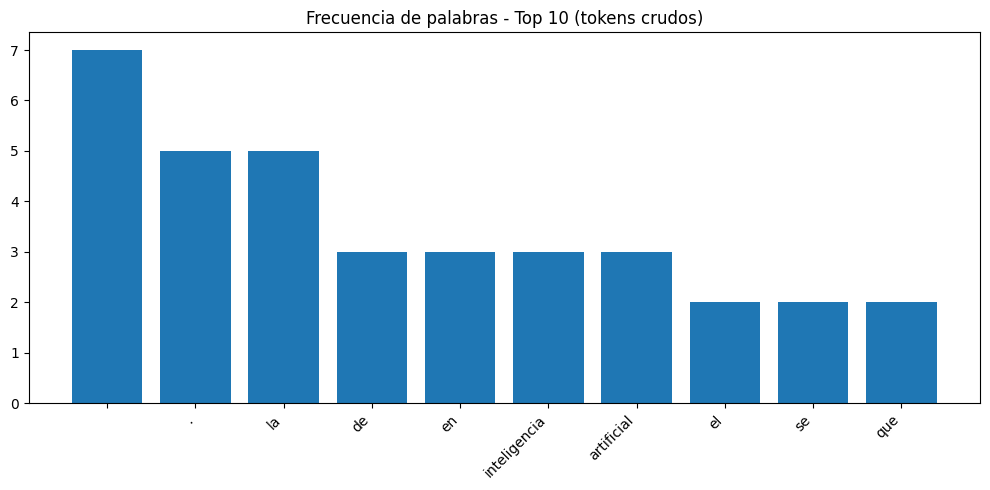

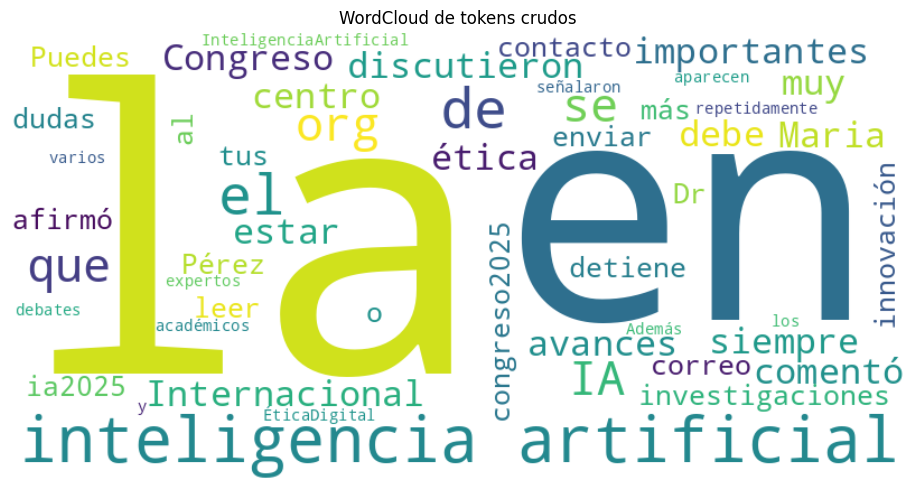

In [81]:
tokens = tokenizar_visualizar(texto, nlp, top_n=10)


### Lematización


=== Lemas ===
['en', 'el', 'Congreso', 'Internacional', 'de', 'Inteligencia', 'Artificial', '2025', 'él', 'discutir', 'avance', 'mucho', 'importante', '@mario', 'comentar', 'que', 'el', 'ética', 'de', 'el', 'IA', 'deber', 'estar', 'siempre', 'en', 'el', 'centro', 'de', 'el', 'investigación', 'Puedes', 'leer', 'más', 'en', 'http://ia-congreso2025.org', 'o', 'enviar', 'tu', 'duda', 'al', 'correo', 'contacto@ia2025.org', 'el', 'Dr.', 'Pérez', 'afirmar', 'el', 'innovación', 'no', 'él', 'detener', 'InteligenciaArtificial', 'éticadigital', 'además', 'varios', 'experto', 'señalar', 'que', 'el', 'inteligencia', 'artificial', 'el', 'inteligencia', 'artificial', 'y', 'el', 'inteligencia', 'artificial', 'aparecer', 'repetidamente', 'en', 'el', 'debate', 'académico']


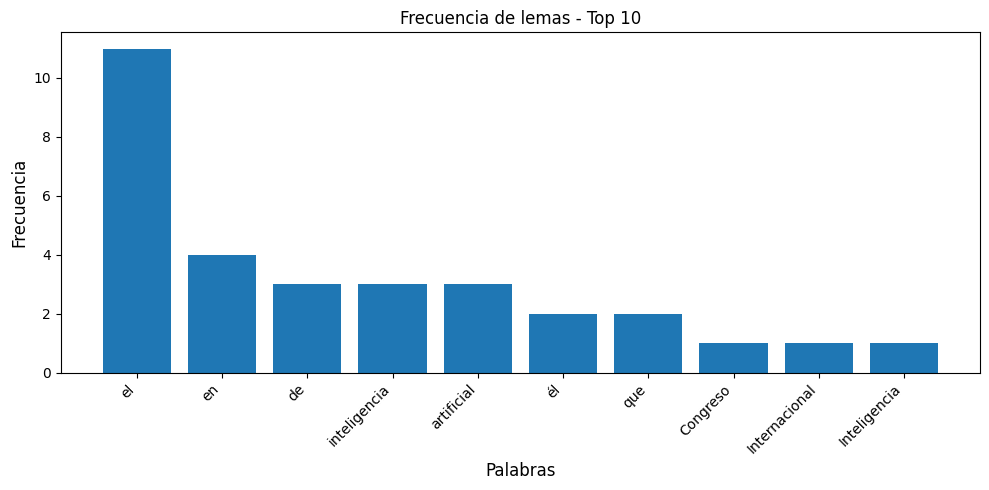

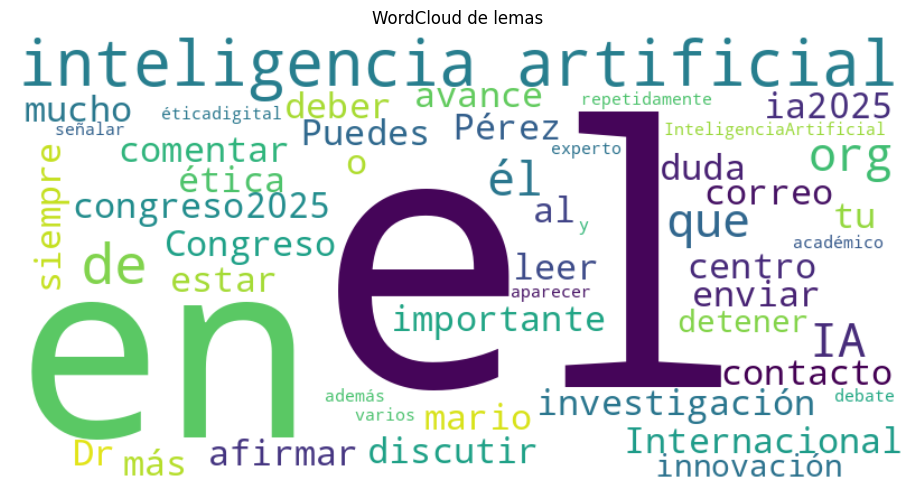

In [84]:
lemmas = lematizar_visualizar(texto, nlp, top_n=10)


#### Tokens sin Stopwords


=== Tokens limpios (sin stopwords) ===
['Congreso', 'Internacional', 'Inteligencia', 'Artificial', '2025', 'discutir', 'avance', 'importante', '@mario', 'comentar', 'ética', 'IA', 'deber', 'siempre', 'centro', 'investigación', 'Puedes', 'leer', 'http://ia-congreso2025.org', 'enviar', 'duda', 'correo', 'contacto@ia2025.org', 'Dr.', 'Pérez', 'afirmar', 'innovación', 'detener', 'InteligenciaArtificial', 'éticadigital', 'además', 'varios', 'experto', 'señalar', 'inteligencia', 'artificial', 'inteligencia', 'artificial', 'inteligencia', 'artificial', 'aparecer', 'repetidamente', 'debate', 'académico']


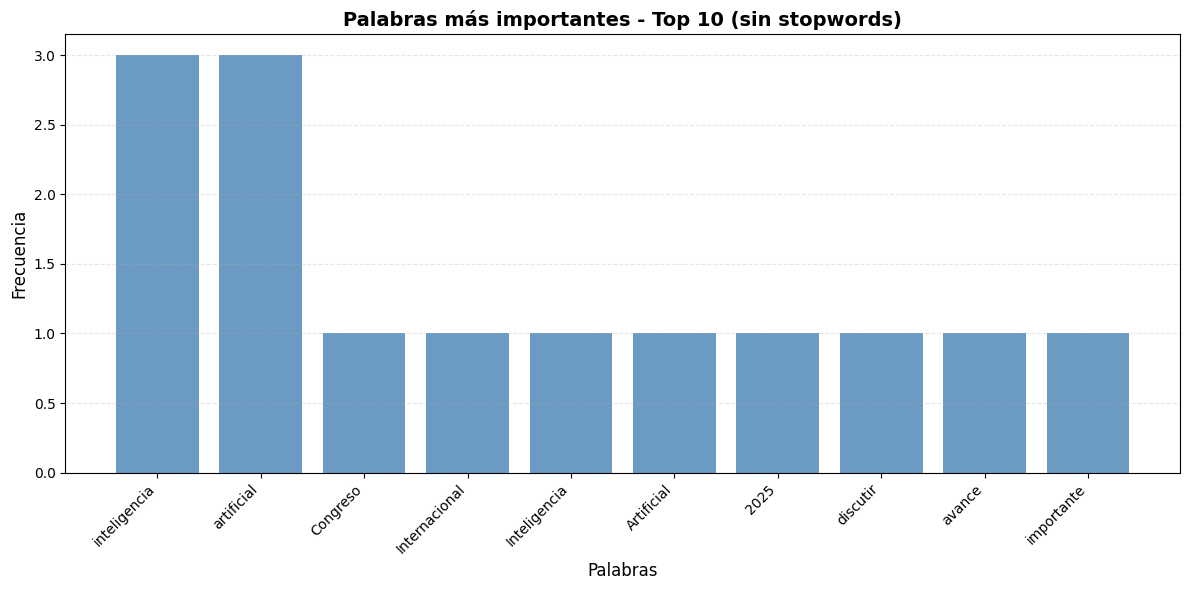

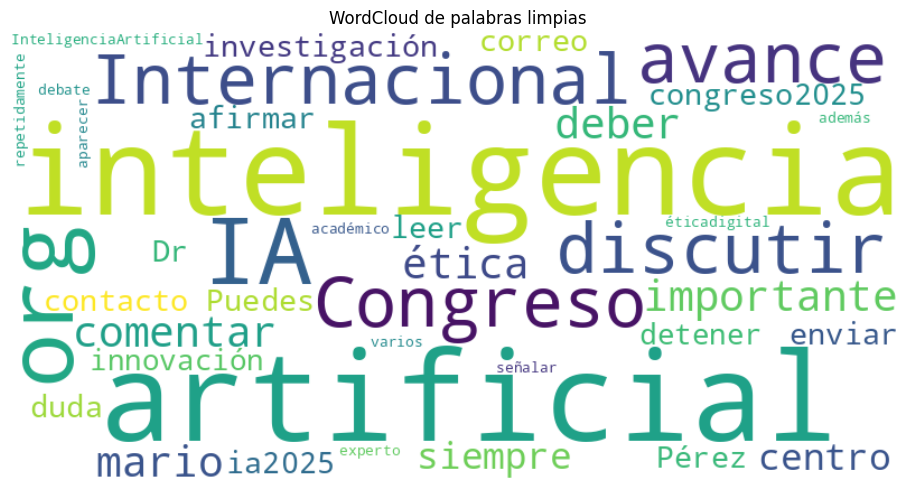

In [85]:
tokens_clean = quitar_stopwords_visualizar(lemmas, top_n=10)
